# Specific Stock Simulation


In [1]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [2]:
ticker = "PDD"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "max"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [3]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [4]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [5]:
simulation_result["price_history"]

,Date,Open,Close,Trade_Price
0,2018-07-26,26.500000,26.700001,26.600000
1,2018-07-27,27.540001,24.600000,26.070001
2,2018-07-30,23.309999,22.500000,22.905000
3,2018-07-31,22.200001,22.590000,22.395000
4,2018-08-01,19.379999,20.309999,19.844999
...,...,...,...,...
1913,2026-03-09,101.010002,102.639999,101.825001
1914,2026-03-10,103.529999,104.860001,104.195000
1915,2026-03-11,104.629997,102.940002,103.785000
1916,2026-03-12,102.529999,101.620003,102.075001


In [6]:
simulation_result["daily_history"]

,Date,Open,Close,Trade_Price,signal_text,signal_number,action,trade_units,trade_value,cash_balance,units_held,average_cost_per_unit,holdings_value,portfolio_value,profit_loss,profit_loss_pct
0,2018-07-26,26.500000,26.700001,26.600000,STRONG BUY,2,BUY,0.375940,10.000000,90.000000,0.375940,26.600000,10.037594,100.037594,0.037594,0.037594
1,2018-07-27,27.540001,24.600000,26.070001,STRONG BUY,2,BUY,0.383583,10.000000,80.000000,0.759522,26.332334,18.684254,98.684254,-1.315746,-1.315746
2,2018-07-30,23.309999,22.500000,22.905000,STRONG BUY,2,BUY,0.436586,10.000000,70.000000,1.196108,25.081339,26.912439,96.912439,-3.087561,-3.087561
3,2018-07-31,22.200001,22.590000,22.395000,STRONG BUY,2,BUY,0.446528,10.000000,60.000000,1.642637,24.351095,37.107162,97.107162,-2.892838,-2.892838
4,2018-08-01,19.379999,20.309999,19.844999,WEAK BUY,1,BUY,0.251953,5.000000,55.000000,1.894589,23.751850,38.479107,93.479107,-6.520893,-6.520893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,2026-03-09,101.010002,102.639999,101.825001,STRONG BUY,2,HOLD,0.000000,0.000000,0.000000,0.299554,113.732774,30.746188,30.746188,-69.253812,-69.253812
1914,2026-03-10,103.529999,104.860001,104.195000,WEAK BUY,1,HOLD,0.000000,0.000000,0.000000,0.299554,113.732774,31.411198,31.411198,-68.588802,-68.588802
1915,2026-03-11,104.629997,102.940002,103.785000,STRONG SELL,-2,SELL,0.029955,3.108918,3.108918,0.269598,113.732774,27.752450,30.861368,-69.138632,-69.138632
1916,2026-03-12,102.529999,101.620003,102.075001,WEAK SELL,-1,SELL,0.013480,1.375962,4.484880,0.256118,113.732774,26.026751,30.511631,-69.488369,-69.488369


In [7]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2018-07-26,BUY,STRONG BUY,26.600000,0.375940,10.000000,90.000000,0.375940,100.037594
1,2018-07-27,BUY,STRONG BUY,26.070001,0.383583,10.000000,80.000000,0.759522,98.684254
2,2018-07-30,BUY,STRONG BUY,22.905000,0.436586,10.000000,70.000000,1.196108,96.912439
3,2018-07-31,BUY,STRONG BUY,22.395000,0.446528,10.000000,60.000000,1.642637,97.107162
4,2018-08-01,BUY,WEAK BUY,19.844999,0.251953,5.000000,55.000000,1.894589,93.479107
...,...,...,...,...,...,...,...,...,...
692,2026-03-04,SELL,WEAK SELL,101.420002,0.011502,1.166534,8.258646,0.218538,30.372520
693,2026-03-05,SELL,WEAK SELL,100.684998,0.010927,1.100176,9.358822,0.207611,30.273576
694,2026-03-06,BUY,STRONG BUY,101.790001,0.091942,9.358822,0.000000,0.299554,30.545488
695,2026-03-11,SELL,STRONG SELL,103.785000,0.029955,3.108918,3.108918,0.269598,30.861368


In [8]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2018-07-26,2026-03-13,100.0,4.48488,0.256118,113.732774,102.650002,26.290553,30.775433,-69.224567,-69.224567,174,523


## Block 6: Consolidated Chart


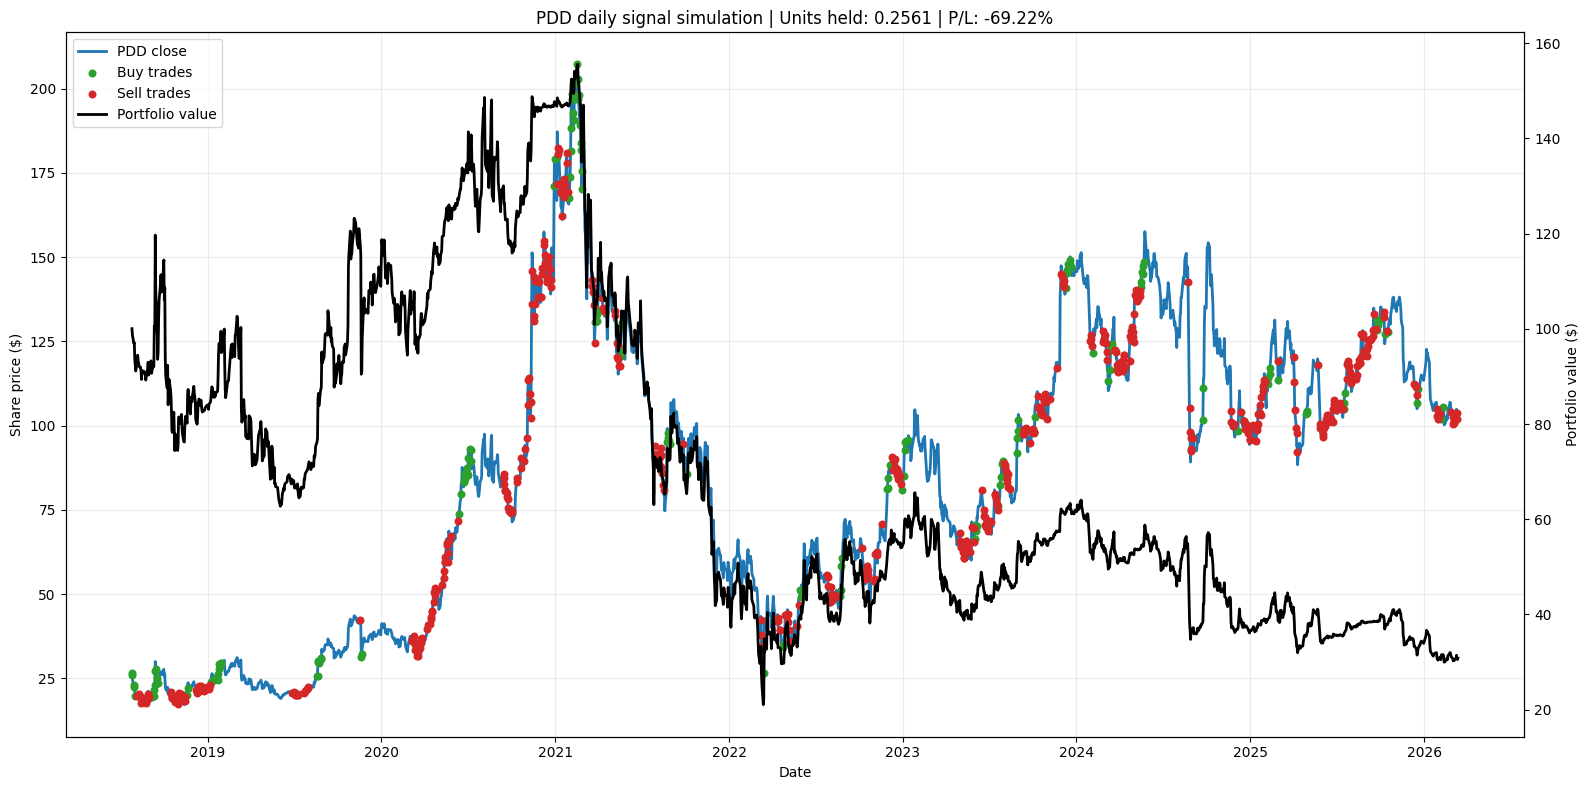

In [9]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [10]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2018-07-26,STRONG BUY,BUY,0.375940,10.000000,90.000000,0.375940,10.037594,100.037594,0.037594
1,2018-07-27,STRONG BUY,BUY,0.383583,10.000000,80.000000,0.759522,18.684254,98.684254,-1.315746
2,2018-07-30,STRONG BUY,BUY,0.436586,10.000000,70.000000,1.196108,26.912439,96.912439,-3.087561
3,2018-07-31,STRONG BUY,BUY,0.446528,10.000000,60.000000,1.642637,37.107162,97.107162,-2.892838
4,2018-08-01,WEAK BUY,BUY,0.251953,5.000000,55.000000,1.894589,38.479107,93.479107,-6.520893
...,...,...,...,...,...,...,...,...,...,...
1913,2026-03-09,STRONG BUY,HOLD,0.000000,0.000000,0.000000,0.299554,30.746188,30.746188,-69.253812
1914,2026-03-10,WEAK BUY,HOLD,0.000000,0.000000,0.000000,0.299554,31.411198,31.411198,-68.588802
1915,2026-03-11,STRONG SELL,SELL,0.029955,3.108918,3.108918,0.269598,27.752450,30.861368,-69.138632
1916,2026-03-12,WEAK SELL,SELL,0.013480,1.375962,4.484880,0.256118,26.026751,30.511631,-69.488369
